In [1]:
import cv2
import numpy as np

# --------------------------------------------------
# Load image (change path)
# --------------------------------------------------
IMG_PATH = "c1.png"  # or extract a frame from your video

img = cv2.imread(IMG_PATH)
if img is None:
    raise RuntimeError("Image not found")

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# --------------------------------------------------
# Mouse callback
# --------------------------------------------------
def mouse_callback(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        b, g, r = img[y, x]
        h, s, v = hsv[y, x]
        print(f"Pixel at ({x},{y})")
        print(f"  BGR = ({b}, {g}, {r})")
        print(f"  HSV = ({h}, {s}, {v})")
        print("-" * 30)

# --------------------------------------------------
# Display
# --------------------------------------------------
cv2.namedWindow("HSV Inspector", cv2.WINDOW_NORMAL)
cv2.setMouseCallback("HSV Inspector", mouse_callback)

while True:
    cv2.imshow("HSV Inspector", img)
    key = cv2.waitKey(1)
    if key == 27:  # ESC
        break

cv2.destroyAllWindows()

Pixel at (409,397)
  BGR = (89, 101, 149)
  HSV = (6, 103, 149)
------------------------------
Pixel at (394,539)
  BGR = (76, 84, 125)
  HSV = (5, 100, 125)
------------------------------
Pixel at (586,383)
  BGR = (131, 137, 185)
  HSV = (3, 74, 185)
------------------------------
Pixel at (323,422)
  BGR = (71, 75, 106)
  HSV = (3, 84, 106)
------------------------------
Pixel at (472,620)
  BGR = (97, 94, 168)
  HSV = (179, 112, 168)
------------------------------
Pixel at (471,625)
  BGR = (24, 20, 90)
  HSV = (178, 198, 90)
------------------------------
Pixel at (474,617)
  BGR = (98, 96, 161)
  HSV = (179, 103, 161)
------------------------------


KeyboardInterrupt: 

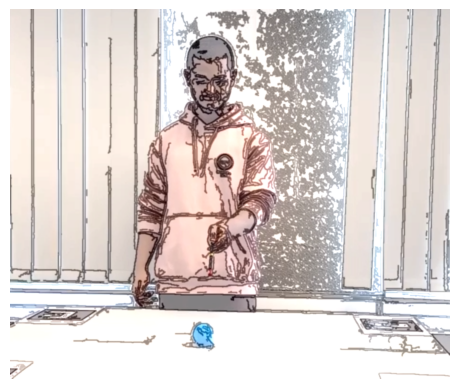

In [26]:
import cv2
import matplotlib.pyplot as plt
IMG_PATH = "c1.png"
img = cv2.imread(IMG_PATH)
def sketch_overlay(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (9, 9), 1)

    edges = cv2.Canny(blur, 00, 30)
    edges = cv2.dilate(edges, None, iterations=1)
    edges = cv2.GaussianBlur(edges, (5, 5), 0)

    edges_col = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)
    edges_col = 255 - edges_col  # invert

    return cv2.addWeighted(frame, 1.0, edges_col, 0.5, 0)


# Convert BGR → RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Plot
plt.imshow(sketch_overlay(img_rgb))
plt.axis("off")
plt.show()